# Baseline B: Image-Based Deep Learning Models

This notebook implements deep learning models for breast cancer detection using mammographic images.

Two architectures are used:
- ResNet (baseline CNN)
- EfficientNet (modern architecture)

Each image is treated as an independent sample, with labels derived from patient-level annotations.

## Import Required Libraries

This section imports all necessary libraries for data handling, deep learning, and evaluation.

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import random

from torchvision import transforms
from torchvision.models import resnet18, efficientnet_b0, ResNet18_Weights, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

## Set Device (CPU / GPU)

This ensures that training uses GPU if available, otherwise CPU.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# Reproducibility Configuration

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Load Image Labels

Load the processed labels file which contains image IDs and corresponding labels.

In [ ]:
labels_df = pd.read_csv("processed_labels.csv")
labels_df.head()

,image_id,label
0,D1-0001_1-1.png,0
1,D1-0001_1-2.png,0
2,D1-0002_1-1.png,0
3,D1-0002_1-2.png,0
4,D1-0003_1-1.png,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Extract Patient-Level Information

Since multiple images belong to the same patient, we extract a `patient_id` from `image_id` to avoid data leakage during train-validation split.

In [ ]:
labels_df['patient_id'] = labels_df['image_id'].apply(lambda x: x.split('_')[0])

labels_df.head()

,image_id,label,patient_id
0,D1-0001_1-1.png,0,D1-0001
1,D1-0001_1-2.png,0,D1-0001
2,D1-0002_1-1.png,0,D1-0002
3,D1-0002_1-2.png,0,D1-0002
4,D1-0003_1-1.png,0,D1-0003


## Custom Dataset Class

This class loads images and corresponding labels for training.

In [ ]:
class BreastCancerDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        label = self.df.loc[idx, 'label']

        img_path = os.path.join(self.image_dir, img_name)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing: {img_path}")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

## Image Transformations

Apply preprocessing and augmentation techniques to improve model generalisation.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Patient-Level Data Splitting

To prevent data leakage, we split the dataset based on unique patient IDs instead of individual images.
This ensures that images from the same patient do not appear in both training and validation sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Unique patient IDs
patient_ids = labels_df['patient_id'].unique()

# Split patients
train_ids, val_ids = train_test_split(
    patient_ids,
    test_size=0.3,
    random_state=42
)

# Create datasets
train_df = labels_df[labels_df['patient_id'].isin(train_ids)]
val_df = labels_df[labels_df['patient_id'].isin(val_ids)]

print("Train patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Train images:", len(train_df))
print("Validation images:", len(val_df))

Train patients: 952
Validation patients: 408
Train images: 2920
Validation images: 1234


## Copy Data from Drive

In [ ]:
!cp -r /content/drive/MyDrive/Processed_Images /content/
IMAGE_DIR = "/content/Processed_Images"

## Dataset & Sampler

A WeightedRandomSampler is used to ensure balanced learning despite class imbalance.

In [ ]:
train_dataset = BreastCancerDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = BreastCancerDataset(val_df, IMAGE_DIR, val_transform)

y_train = train_df['label'].values

class_sample_count = torch.tensor([
    len(y_train[y_train == 0]),
    len(y_train[y_train == 1])
])

weights = 1. / class_sample_count.float()
samples_weight = torch.tensor([weights[label] for label in y_train])

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, generator=torch.Generator().manual_seed(42))

## Training Function with Loss Tracking

This function trains the model over multiple epochs.

In [ ]:
def train_model(model, train_loader, epochs=15):

    train_losses = []

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss}")

    return model, train_losses

## Evaluation Function

Evaluate model performance using classification metrics.

In [ ]:
def evaluate_model(model, val_loader, threshold=0.45):

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred))

## Define ResNet Model

ResNet is used as a baseline convolutional neural network.

In [ ]:
model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

model_resnet.fc = nn.Sequential(
    nn.Linear(model_resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model_resnet = model_resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


## Train and Evaluate ResNet Model

In [ ]:
model_resnet, resnet_losses = train_model(
    model_resnet,
    train_loader,
    epochs=20
)
evaluate_model(model_resnet, val_loader, threshold=0.55)

Epoch 1, Loss: 0.22743836077659027
Epoch 2, Loss: 0.22513820830246675
Epoch 3, Loss: 0.22288429218789804
Epoch 4, Loss: 0.22198450873079506
Epoch 5, Loss: 0.2201956648217595
Epoch 6, Loss: 0.22297022702253383
Epoch 7, Loss: 0.22298289884043776
Epoch 8, Loss: 0.2346228869712871
Epoch 9, Loss: 0.22849655669668448
Epoch 10, Loss: 0.21925843976761983
Epoch 11, Loss: 0.22233452048638594
Epoch 12, Loss: 0.22702058032155037
Epoch 13, Loss: 0.21579016631712084
Epoch 14, Loss: 0.21987813678772553
Epoch 15, Loss: 0.23360952362418175
Epoch 16, Loss: 0.2162454706495223
Epoch 17, Loss: 0.21686642649381058
Epoch 18, Loss: 0.21168897414337035
Epoch 19, Loss: 0.2256056381308514
Epoch 20, Loss: 0.22248129821989848
              precision    recall  f1-score   support

           0       0.26      0.28      0.27       120
           1       0.92      0.91      0.92      1114

    accuracy                           0.85      1234
   macro avg       0.59      0.60      0.59      1234
weighted avg       0.

## Define EfficientNet Model (Modern Model)

In [ ]:
model_effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model_effnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model_effnet.classifier[1].in_features, 2)
)

model_effnet = model_effnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]


## Train & Evaluate EfficientNet Model

In [ ]:
model_effnet, effnet_losses = train_model(
    model_effnet,
    train_loader,
    epochs=20
)
evaluate_model(model_effnet, val_loader, threshold=0.6)

Epoch 1, Loss: 0.28310703858733177
Epoch 2, Loss: 0.2707817599825237
Epoch 3, Loss: 0.26572614762446156
Epoch 4, Loss: 0.2678091563284397
Epoch 5, Loss: 0.26382941558309225
Epoch 6, Loss: 0.25506264343857765
Epoch 7, Loss: 0.2534913088640441
Epoch 8, Loss: 0.24956784510742064
Epoch 9, Loss: 0.24783597611214803
Epoch 10, Loss: 0.2477254495024681
Epoch 11, Loss: 0.24106133048949036
Epoch 12, Loss: 0.23570136191404384
Epoch 13, Loss: 0.23739642002012418
Epoch 14, Loss: 0.22459614212098328
Epoch 15, Loss: 0.23295958129608113
Epoch 16, Loss: 0.2381733617056971
Epoch 17, Loss: 0.22743698225721068
Epoch 18, Loss: 0.23091990387310152
Epoch 19, Loss: 0.23237386653604714
Epoch 20, Loss: 0.2309460108694823
              precision    recall  f1-score   support

           0       0.24      0.26      0.25       120
           1       0.92      0.91      0.92      1114

    accuracy                           0.85      1234
   macro avg       0.58      0.58      0.58      1234
weighted avg       0.85

## ResNet Training Loss Curve

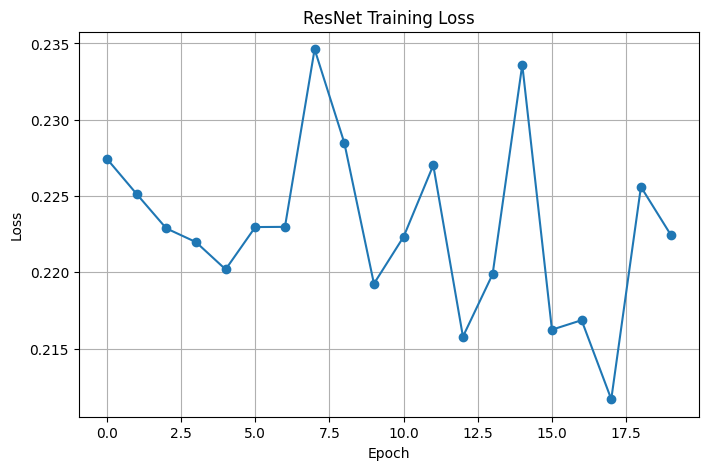

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(resnet_losses, marker='o')

plt.title("ResNet Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

## EfficientNet Training Loss Curve

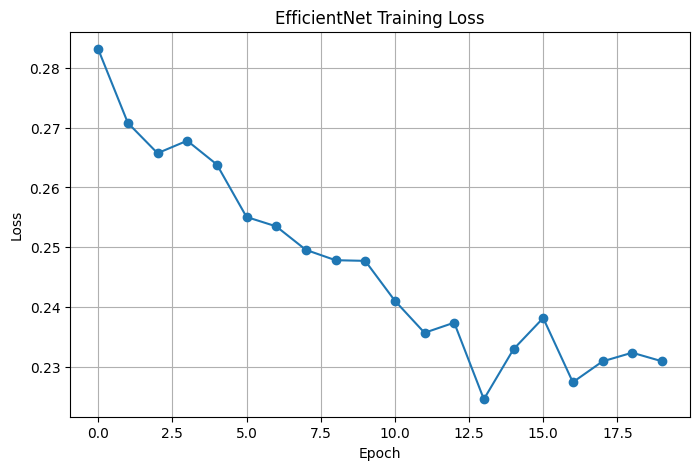

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(effnet_losses, marker='o')

plt.title("EfficientNet Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Baseline B Model Loss Comparison

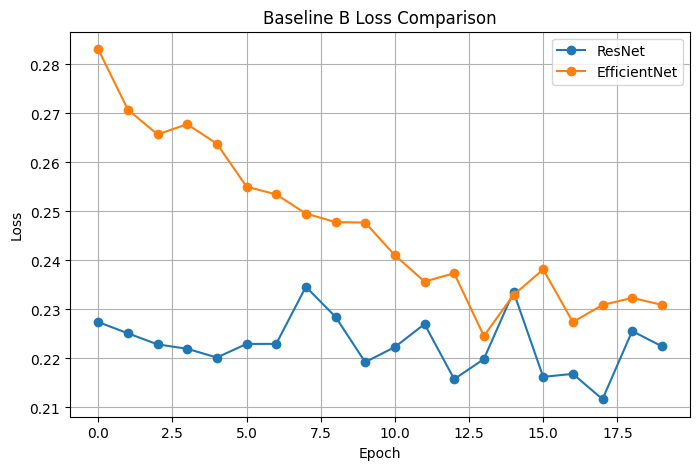

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(resnet_losses, marker='o', label='ResNet')

plt.plot(effnet_losses, marker='o', label='EfficientNet')

plt.title("Baseline B Loss Comparison")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Baseline B Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_baseline(model, loader, threshold=0.45):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:,1]

            preds = (probs >= threshold).long()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title("Baseline B Confusion Matrix")

    plt.show()

## Confusion Matrix for ResNet

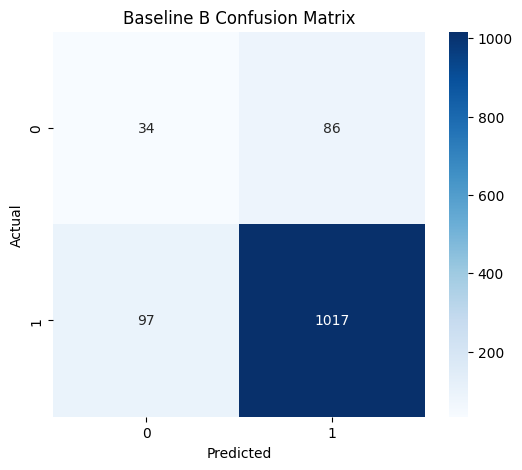

In [ ]:
plot_confusion_matrix_baseline(
    model_resnet,
    val_loader,
    threshold=0.55
)

## Confusion Matrix for EfficientNet

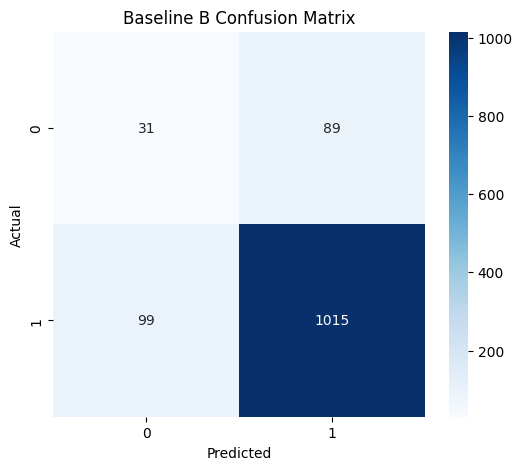

In [ ]:
plot_confusion_matrix_baseline(
    model_effnet,
    val_loader,
    threshold=0.6
)

## Baseline B ROC Curve

In [ ]:
def plot_roc_curve_baseline(model, loader):

    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:,1]

            y_true.extend(labels.numpy())
            y_scores.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, y_scores)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'AUC = {roc_auc:.2f}'
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("Baseline B ROC Curve")

    plt.legend()

    plt.grid(True)

    plt.show()

## ResNet ROC Curve

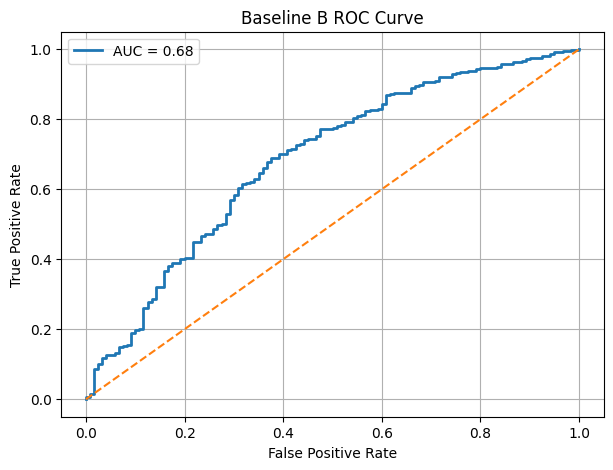

In [ ]:
plot_roc_curve_baseline(
    model_resnet,
    val_loader
)

## EfficientNet ROC Curve

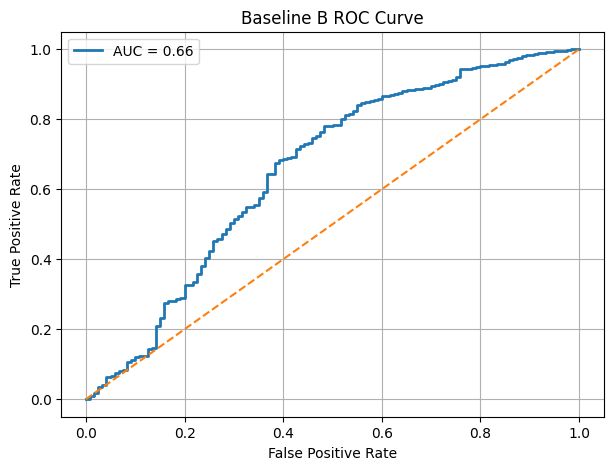

In [ ]:
plot_roc_curve_baseline(
    model_effnet,
    val_loader
)

# ResNet Performance Metrics

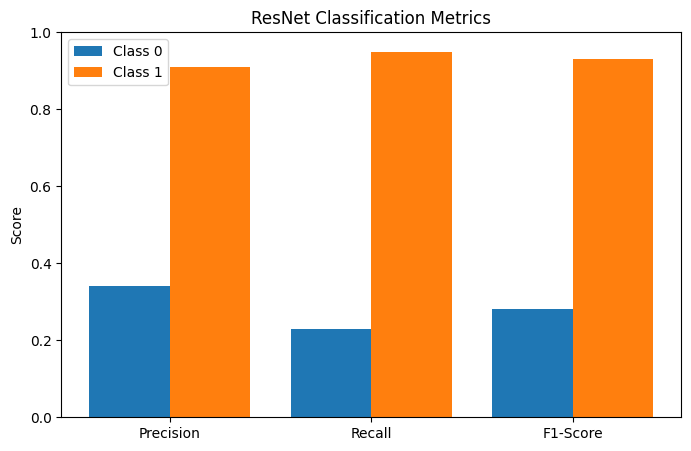

In [ ]:
metrics_names = ['Precision', 'Recall', 'F1-Score']

class_0 = [0.34, 0.23, 0.28]
class_1 = [0.91, 0.95, 0.93]

x = range(len(metrics_names))

plt.figure(figsize=(8,5))

plt.bar(x, class_0, width=0.4, label='Class 0')

plt.bar(
    [i + 0.4 for i in x],
    class_1,
    width=0.4,
    label='Class 1'
)

plt.xticks([i + 0.2 for i in x], metrics_names)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("ResNet Classification Metrics")

plt.legend()

plt.show()

## EfficientNet Performance Metrics

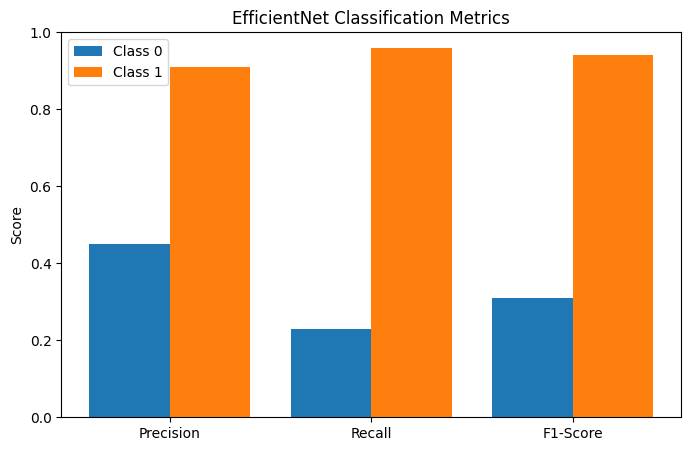

In [ ]:
metrics_names = ['Precision', 'Recall', 'F1-Score']

class_0 = [0.45, 0.23, 0.31]
class_1 = [0.91, 0.96, 0.94]

x = range(len(metrics_names))

plt.figure(figsize=(8,5))

plt.bar(x, class_0, width=0.4, label='Class 0')

plt.bar(
    [i + 0.4 for i in x],
    class_1,
    width=0.4,
    label='Class 1'
)

plt.xticks([i + 0.2 for i in x], metrics_names)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("EfficientNet Classification Metrics")

plt.legend()

plt.show()

## Baseline B Model Comparison

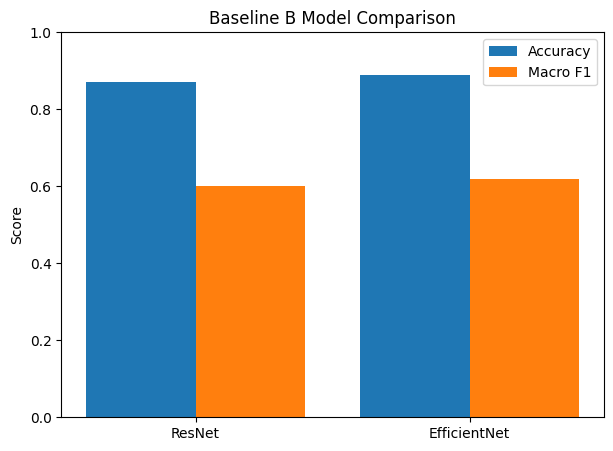

In [ ]:
models = ['ResNet', 'EfficientNet']

accuracy = [0.87, 0.89]

macro_f1 = [0.60, 0.62]

x = range(len(models))

plt.figure(figsize=(7,5))

plt.bar(x, accuracy, width=0.4, label='Accuracy')

plt.bar(
    [i + 0.4 for i in x],
    macro_f1,
    width=0.4,
    label='Macro F1'
)

plt.xticks([i + 0.2 for i in x], models)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Baseline B Model Comparison")

plt.legend()

plt.show()